<div style="
background-color:#fff9c4;
padding:24px;
border-radius:16px;
border:1.5px solid #fbc02d;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h1 style="
margin-top:0;
color:#000000;
text-align:center;
font-size:42px;
font-family:'Palatino Linotype', Palatino, Georgia, serif;
font-weight:700;
letter-spacing:0.8px;
">
¿Puede un observatorio aprender a mirar?
</h1>

<h2 style="
color:#000000;
text-align:center;
font-size:24px;
">
Redes neuronales y perceptrón con una analogía astronómica
</h2>

<!-- <p>
Este notebook está basado en la idea central de la presentación <b>"¿Puede un observatorio aprender a mirar?"</b>.
</p> -->

<p>
La meta es explicar, de forma simple y visual, cómo funciona un <b>perceptrón</b> y por qué una <b>red neuronal</b> puede aprender patrones más complejos.
</p>

<p>
Usaremos una analogía sencilla:
</p>

<ul>
<li>El observatorio recibe mediciones del cielo  ->  una matriz input y un vector de etiquetas</li>
<li>Combina distintas pistas  ->  combinación lineal de pesos y datos</li>
<li>Toma una decisión  ->  perceptrón y su función de activación</li>
<li>Y mejora después de cometer errores  ->  cómo aprende</li>
</ul>

</div>

<div style="
background-color:#ececec;
padding:24px;
border-radius:16px;
border:1.5px solid #b0b0b0;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h2 style="
margin-top:0;
color:#000000;
text-align:center;
font-size:34px;
font-family:'Palatino Linotype', Palatino, Georgia, serif;
font-weight:700;
letter-spacing:0.6px;
">
1. El cielo se convierte en números
</h2>

<p>
Un telescopio no "entiende" una estrella como lo haría una persona.
</p>

<p>
Lo que recibe son <b>mediciones</b>. Por ejemplo:
</p>

<ul>
<li>Brillo.</li>
<li>Cambio de brillo.</li>
<li>Color.</li>
<li>Claridad de la señal.</li>
</ul>

<p>
Donde cada observación tiene valores diferentes de estas cantidades, y las podríamos representar en el espacio euclidiano como las respectivas coordenadas.
Una IA trabaja con esos valores numéricos y aprende a decidir si una señal es interesante o no, si pasa o no, o si es algo o no lo es.
</p>

</div>

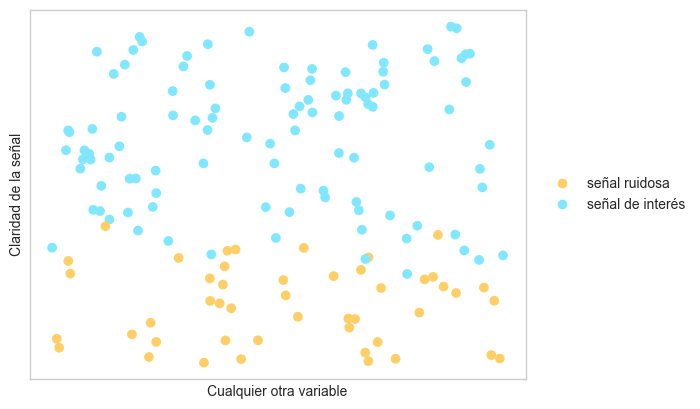

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(12+89)

""" EJEMPLO DE CÓMO SE SEPARAN LOS DATOS """

# Datos del espacio
frontier = 0.33
noise = 0.1

# Creamos datos aleatoreos
N = 150
x = np.linspace(0.0, 1.0, N)
y = np.linspace(0.0, 1.0, N)

example_x = np.random.uniform(0.0, 1.0, N)
example_y = np.random.uniform(0.0, 1.0, N)

# Creamos una frontera imaginaria
labels = np.zeros_like(example_y)

for n in range(labels.shape[0]):

    # Creamos labels binarias con ruido en la frontera para ilustrar
    if example_y[n] < frontier - noise:
        labels[n] = 0
    elif example_y[n] > frontier + noise:
        labels[n] = 1
    # Agregamos ruido en la frontera
    else:
        # Evaluamos el valor normalizado en la frontera
        y_norm = (example_y[n] - (frontier - noise)) / (2. * noise)

        # Creamos la frontera por rechazo
        y_eval = np.random.uniform(0.0, 1.0)

        if y_norm > y_eval:
            labels[n] = 1

        
cmap = plt.get_cmap('managua')
sc = plt.scatter(example_x, example_y, c = labels, cmap = cmap)
plt.ylabel("Claridad de la señal")
plt.xlabel("Cualquier otra variable")

legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=cmap(0.0), markersize=8, label='señal ruidosa'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=cmap(1.0), markersize=8, label='señal de interés')
]

plt.legend(handles=legend_elements,
           loc='center left',
           bbox_to_anchor=(1.02, 0.5))

plt.xticks([])
plt.yticks([])

plt.show()
    
    

<div style="
background-color:#ececec;
padding:24px;
border-radius:16px;
border:1.5px solid #b0b0b0;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<p>
Lo que es de preguntarse ahora es
</p>

<p>
    <b>¿Cómo podemos generar estas fronteras para clasificar los diferentes tipos de señales?</b>
</p>



<div style="
background-color:#ececec;
padding:24px;
border-radius:16px;
border:1.5px solid #b0b0b0;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h2 style="
margin-top:0;
color:#000000;
text-align:center;
font-size:34px;
font-family:'Palatino Linotype', Palatino, Georgia, serif;
font-weight:700;
letter-spacing:0.6px;
">
2. El perceptrón: un astrónomo de una sola pregunta
</h2>

<p>
El perceptrón es la neurona artificial más simple.
</p>

<p>
Su pregunta es básicamente esta:
</p>

<blockquote style="
background:#f7f7f7;
border-left:5px solid #7a7a7a;
padding:12px 16px;
border-radius:8px;
font-style:italic;
">
Con estas mediciones, ¿la señal parece candidata o no?
</blockquote>

<p>
Para responderla, tiene que tomar de alguna u otra manera una decisión, y al tratarse de una decisión <b>binaria</b>, lo más sencillo es trazar una frontera en el espacio de las mediciones a partir de la cual decide
</p>

<blockquote style="
background:#f7f7f7;
border-left:5px solid #7a7a7a;
padding:12px 16px;
border-radius:8px;
font-style:italic;
">
las mediciones de un lado son x, y las del otro no lo son
</blockquote>

<p>
Matemáticamente, considerando todas las posibles dimensiones, la frontera más simple se vería como un <b>hiperplano</b> definido por
</p>

$$
\sum_{n = 1}^{N} w_n x_n + b = 0
$$

<p>
Luego, para saber en qué lado del espacio cae una cierta medición $\{ \hat x_n \}_{n}^N$, sólo se evalua:
</p>

$$
z = \sum_{n = 1}^{N} w_n \hat{x}_n + b
$$

<p>
Y se decide acorde a:
</p>

<ul>
<li>Si <code>z ≥ 0</code>, responde <code>1</code>.</li>
<li>Si <code>z &lt; 0</code>, responde <code>0</code>.</li>
</ul>



<p>
En el caso del ejemplo anterior, una frontera que separa bien los diferentes datos es
</p>


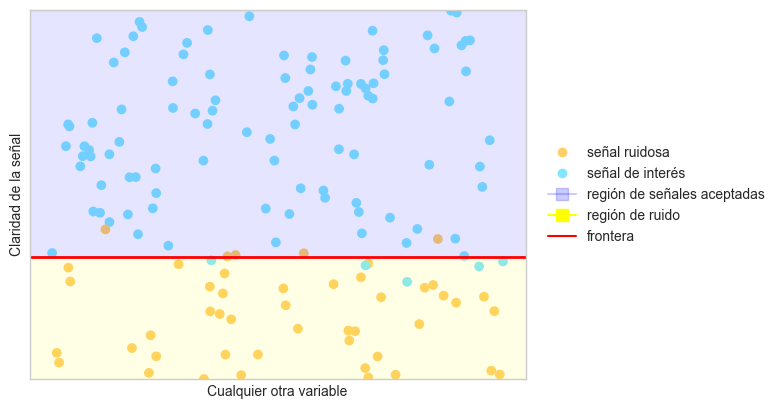

In [2]:
cmap = plt.get_cmap('managua')
sc = plt.scatter(example_x, example_y, c = labels, cmap = cmap)
plt.ylabel("Claridad de la señal")
plt.xlabel("Cualquier otra variable")


plt.axhspan(ymin=0.33, ymax=1.0, color='blue', alpha=0.1)
plt.axhspan(ymin=0., ymax=0.33, color='yellow', alpha=0.1)

legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=cmap(0.0), markersize=8, label='señal ruidosa'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=cmap(1.0), markersize=8, label='señal de interés'),
    
    Line2D([0], [0], marker='s', color='blue', markersize=8, alpha = 0.2, label='región de señales aceptadas'),
    Line2D([0], [0], marker='s', color='yellow', markersize=8, alpha = 1.0, label='región de ruido'),
    
    Line2D([0], [0], linestyle='-', color='r',
           markerfacecolor="r", markersize=8, label='frontera')
]

plt.legend(handles=legend_elements,
           loc='center left',
           bbox_to_anchor=(1.02, 0.5))

plt.axhline(y=0.33, color='red', linestyle='-', linewidth=2)
plt.ylim(0.0, 1.0)
plt.xticks([])
plt.yticks([])

plt.show()

<div style="
background-color:#ececec;
padding:24px;
border-radius:16px;
border:1.5px solid #b0b0b0;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<p>
La pregunta natural que sigue es
</p>

<blockquote style="
background:#f7f7f7;
border-left:5px solid #7a7a7a;
padding:12px 16px;
border-radius:8px;
font-style:italic;
">
¿Cómo podemos definir esta frontera?
</blockquote>


<p>
De eso se encarga el <b>perceptron</b>
</p>


<p>
Para ilustrarlo, imaginemos un set de datos algo más complejo con sólo 2 variables. El hiperplano (o línea recta) que tracemos en esta ocasión viene descrita por
</p> 


$$
w_0 x + w_1 y + b = 0
$$


<p>
donde $w$ son los pesos y $b$ es el sesgo del perceptron. 

Ahora, lo que nos interesa es saber qué valores de $w_0$ y $w_1$, junto con $b$, resultan en la mejor frontera que separa los dos clusters de datos.
</p> 


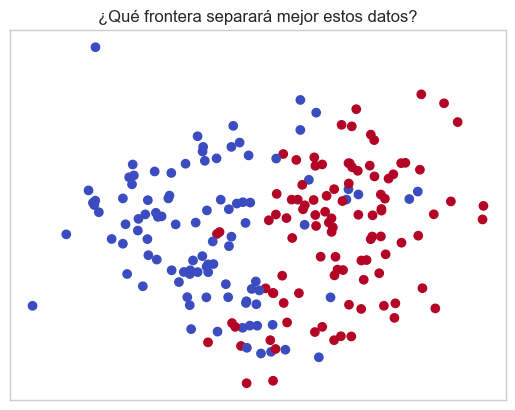

In [25]:
from sklearn.datasets import make_classification

# Creamos un set de datos artificiales
X, y = make_classification(
    n_samples=200,          
    n_features=2,           
    n_informative=2,        
    n_redundant=0,          
    n_clusters_per_class=2, 
    flip_y=0.0,            
    random_state=42         
)


# Mostramos los datos
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm')
plt.xticks([])
plt.yticks([])
plt.title("¿Qué frontera separará mejor estos datos?")
plt.show()

<div style="
background-color:#ececec;
padding:24px;
border-radius:16px;
border:1.5px solid #b0b0b0;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<p>
pero para ello, vale la pena tener una intuición de lo que estamos haciendo, y sobre todo, de las variables que necesitamos modificar. 
</p>


<div style="
background-color:#ececec;
padding:24px;
border-radius:16px;
border:1.5px solid #b0b0b0;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h2 style="
margin-top:0;
color:#000000;
text-align:center;
font-size:34px;
font-family:'Palatino Linotype', Palatino, Georgia, serif;
font-weight:700;
letter-spacing:0.6px;
">
Los pesos: ¿qué pista importa más?
</h2>

<p>
No todas las pistas cuentan igual.
</p>

<p>
Si una medición tiene un peso alto, influye más en la decisión.
</p>

<p>
Eso significa que el perceptrón, luego de <b>haber encontrado la frontera correcta</b>, aprende qué pistas son más útiles para detectar una señal interesante.
</p>

<p>
En el caso de nuestro ejemplo 2D, podemos trazar nuestra frontera como una recta
</p>


$$
y = -\frac{w_0}{w_1}x - b = -mx - b
$$


<p>
donde podemos ver, en general, que si $m$ crece, entonces el eje $y$ pierde representatividad al ser menos importante para dividir el espacio, y eso ocurre tanto si $w_0$ (el peso del eje x) crece o si $w_1$ (el del eje y) disminuye. En los casos extremos en donde $m=0$ o $m\to\infty$, entonces sólo 1 eje es representativo. 
</p>



</div>

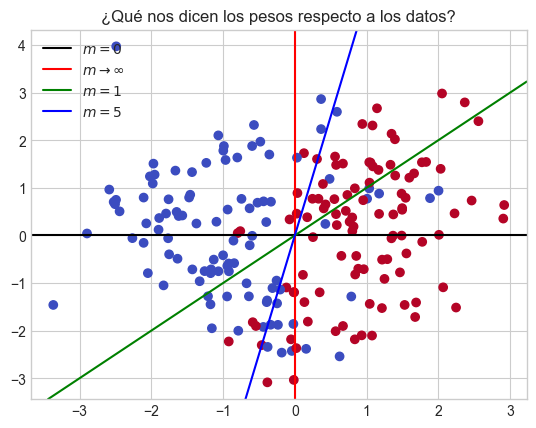

In [26]:
# Mostramos los datos
fig, ax = plt.subplots()
ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm')

# Trazamos las "fronteras"
ax.axline((0, 0), slope=0, c = 'black', label=r'$m=0$')
ax.axline((0, 0), slope=99999999., c = 'red', label=r'$m\to\infty$')
ax.axline((0, 0), slope=1.0, c = 'green', label=r'$m=1$')
ax.axline((0, 0), slope=5.0, c = 'blue', label=r'$m=5$')

ax.legend()

ax.set_title("¿Qué nos dicen los pesos respecto a los datos?")
plt.show()

<div style="
background-color:#ececec;
padding:24px;
border-radius:16px;
border:1.5px solid #b0b0b0;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h2 style="
margin-top:0;
color:#000000;
text-align:center;
font-size:34px;
font-family:'Palatino Linotype', Palatino, Georgia, serif;
font-weight:700;
letter-spacing:0.6px;
">
El sesgo: ¿qué tan exigente es el observatorio?
</h2>

<p>
El sesgo funciona como un <b>nivel mínimo</b> para activar la alerta.
</p>

<ul>
<li>Un sesgo más alto hace al sistema más exigente.</li>
<li>Un sesgo más bajo hace al sistema más sensible.</li>
</ul>

<p>
En otras palabras, el sesgo mueve el punto en el que el observatorio dice: <i>"esto ya vale la pena"</i>.
</p>


<p>
En el ejemplo anterior, este se ve como el intercepto de la línea que estamos usando como frontera. 
    
* Entre más positivo sea $b$, entonces más se separa de la frontera imaginaria original, adentránse más profundo en la región de interés, haciendo que puntos "ruidosos" sean más difíciles de considerar.
* Caso contrario ocurre cuando hacemos $b$ negativo, pues entonces la frontera se adentra a la zona "no interesante", y permite que puntos que se encuentren más cercanos a la frontera original sean aceptados. 
</p>

</div>

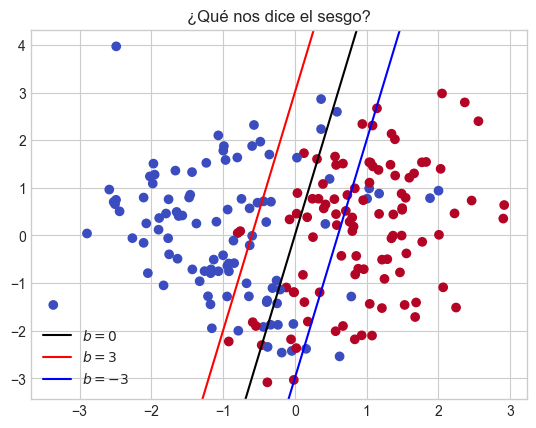

In [27]:
# Mostramos los datos
fig, ax = plt.subplots()
ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm')

# Trazamos la frontera
ax.axline((0, 0), slope=5.0, c = 'black', label=r'$b=0$')
ax.axline((0, 3), slope=5.0, c = 'red', label=r'$b=3$')
ax.axline((0, -3), slope=5.0, c = 'blue', label=r'$b=-3$')

ax.legend()

ax.set_title("¿Qué nos dice el sesgo?")
plt.show()

<div style="
background-color:#ececec;
padding:24px;
border-radius:16px;
border:1.5px solid #b0b0b0;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h2 style="
margin-top:0;
color:#000000;
text-align:center;
font-size:34px;
font-family:'Palatino Linotype', Palatino, Georgia, serif;
font-weight:700;
letter-spacing:0.6px;
">
Activación: sí, no o casi
</h2>

<p>
Finalmente, hace falta definir la <b>activación</b>. Para ello, pensemos en lo siguiente:

* Nuestros datos, de momento, son $1$ o $0$
* Al momento de evaluar el dato usando $z = \sum w_n \hat x_n + b$, $z$, que se puede extender de $-\infty$ a $\infty$, rara vez será $0$ o $1$
* Tenemos que mapear, de alguna forma, todos los valores de $z$ de modo tal que le output total sea $0$ o $1$ (o algún número en medio, según sea el caso) 
</p>

<p>
Este es el trabajo de las <b>funciones de activación</b>, de las que hay muchas y de todos los sabores: escalera, sigmoide, tanh, relu, softmax, ... Y cada una tiene una función diferente y se usa para distintos casos.
</p>


<p>
En este caso, donde nos interesa únicamente tener valores binarios, la función escalón es la más apropiada, y se define como
</p>


$$
\phi(z) = \left\{ 
\begin{matrix}
0 && z < 0 \\ 
1 && z \ge 0
\end{matrix}
\right.
$$


<p>
Incluso, en algunos casos (visto mucho en redes neurales), vale la pena utilizar funciones que mapean al intervalo $[0, \,1]$ para expresar <b>qué tan segura está la red de que el dato sea aceptable o no</b>, y para esto se utilizan funciones que mapean $\mathbb{R} \to [0, \,1]$, como lo es la función sigmoide
</p>

$$
    \phi(z) = \frac{1}{1 + e^{-x}}
$$

<p>
Inclusive, en la mayoría de casos, como regresión, se utilizan funciones que mapean a otros intervalos, o incluso a $\mathbb{R}$, como $\tanh(z)$
</p>


</div>

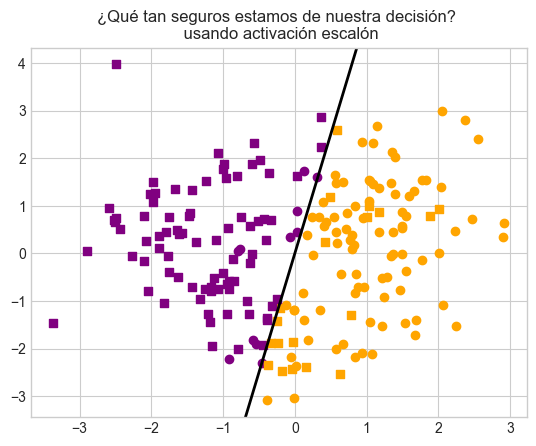

In [28]:
# Modificamos marcadores para mostrar mejor la vaina
M = ["s" if lab == 0 else "o" for lab in y]

# Evaluamos el score de cada punto
def evaluate_point(x, y):

    z = -y + 5.0*x 

    def heavyside(z):
        return 0 if z < 0 else 1

    return "purple" if heavyside(z) == 0 else "orange"

PHIZ = [evaluate_point(x, y) for x, y in zip(X[:,0], X[:,1])]

# Mostramos los datos
fig, ax = plt.subplots()

for x, m, c in zip(X, M, PHIZ):
    ax.scatter(x[0], x[1], marker=m, color=c)

# Trazamos la frontera
ax.axline((0, 0), slope=5.0, c = 'black', lw = 2.0)


ax.set_title("¿Qué tan seguros estamos de nuestra decisión? \n usando activación escalón")
plt.show()

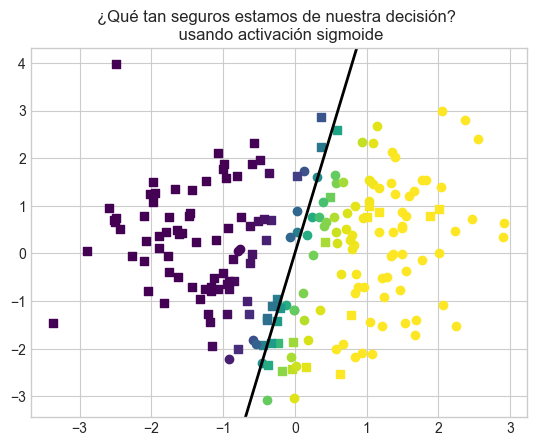

In [29]:
# Modificamos marcadores para mostrar mejor la vaina
M = ["s" if lab == 0 else "o" for lab in y]

# Evaluamos el score de cada punto
def evaluate_point(x, y):

    z = -y + 5.0*x 

    def sigmoid(z):
        return 1. / (1 + np.exp(-z))

    return sigmoid(z)

PHIZ = [evaluate_point(x, y) for x, y in zip(X[:,0], X[:,1])]


# Mostramos los datos
fig, ax = plt.subplots()

for x, m, c in zip(X, M, PHIZ):
    ax.scatter(x[0], x[1], marker=m, color=plt.cm.viridis(c))

# Trazamos la frontera
ax.axline((0, 0), slope=5.0, c = 'black', lw = 2.0)


ax.set_title("¿Qué tan seguros estamos de nuestra decisión? \n usando activación sigmoide")
plt.show()

<div style="
background-color:#ececec;
padding:24px;
border-radius:16px;
border:1.5px solid #b0b0b0;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h2 style="
margin-top:0;
color:#000000;
text-align:center;
font-size:34px;
font-family:'Palatino Linotype', Palatino, Georgia, serif;
font-weight:700;
letter-spacing:0.6px;
">
3. ¿Cómo aprende el perceptrón?
</h2>



<p>
Ya que conocemos cada parte del proceso, y sabemos que el perceptron, a fin de cuentas, es un evaluador que toma inputs de una medición $\vec{\hat x}_j$ y escupe un output $z_j$ (el cual, idealmente, debe ser igual a la observación $\hat y_j$), lo podemos escribir como 
</p>

$$
\phi\left( \vec w^\top \vec{\hat x}_j + b \right) = {z}_j
$$

<p>
y nuestra meta es hace que, modificando únicamente los pesos $\vec w$, $z_j \to \hat y_j$, y para ello, se tiene el siguiente proceso de aprendizaje:
</p>


<ol>
<li>Mide la señal.</li>
<li>Predice una clase.</li>
<li>Compara con la respuesta correcta.</li>
<li>Ajusta sus pesos.</li>
</ol>

<p>
La regla de aprendizaje es, para cada una de las etapas $i$ donde utilizaremos alguno de los datos $j$:
</p>

$$
\vec w^{i+1} = \vec w^{i} + \eta \left({\hat y}_j - z_j^{i} \right) \vec{\hat x}_j
$$

$$
b^{i+1} = b^{i} + \eta \left(\hat y_j - z^i_j \right)
$$

<p>
donde $\eta$ es el <b>paso de aprendizaje</b>, e indica qué tanto se van a modificar los pesos y el bias.
</p>

<p>
Ahora, en la práctica, se utiliza una formulación que permite considerar todas las muestras en una sola iteración
</p>

$$
\vec w^{i+1} = \vec w^{i} + \eta \cdot \mathbf{X}^t \left( \vec{\hat y} - \vec z^i \right)
$$
$$
b^{i+1} = b^{i} + \eta \cdot \sum_k \left( {\hat y}_k -  z^i_k \right)
$$

</div>

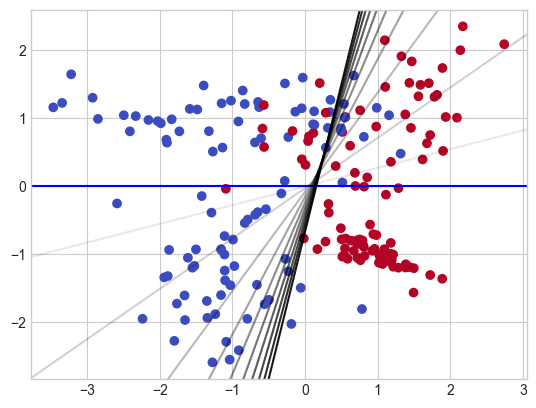

In [54]:
# Creamos el vector de pesos y el escalar de bias globales
w = np.array([0.,-9.0])
b = 0.0

# Paso de aprendizaje
eta = 0.02

# Función de activación
def activation(x):
    return 1. / (1 + np.exp(-x))

# Evaluación del perceptron
def perceptron_predict(w, b, X = X):
    return activation( X@w + b)

# Definimos el paso del perceptron
def perceptron_step(w, b, X = X, y = y):

    # Predicción del perceptron
    z = perceptron_predict(w, b, X)
    
    # regla de actualización del peso 
    w += eta * X.T@(y - z)

    # regla de actualización del bias
    b += eta * np.sum(y - z)

    return w, b

# Mostramos los datos

N = 10

fig, ax = plt.subplots()
ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm')
ax.axline((0, -b/w[1]), slope= -w[0] / w[1], c = 'blue')

# Corremos el perceptron por ciertas iteraciones
for i in range(N):
    w, b = perceptron_step(w, b, X = X, y = y)
    
    # Trazamos la frontera
    ax.axline((0, -b/w[1]), slope= -w[0] / w[1], c = 'black', alpha = (i + 1)/(N+1))

plt.show()

<div style="
background-color:#ececec;
padding:24px;
border-radius:16px;
border:1.5px solid #b0b0b0;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">


<p>
Pudiendo ver cómo, poco a poco, el perceptron es capaz de converger hacia una frontera que efectivamente separa los datos.
</p>


</div>

<div style="
background-color:#ececec;
padding:24px;
border-radius:16px;
border:1.5px solid #b0b0b0;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h2 style="
margin-top:0;
color:#000000;
text-align:center;
font-size:34px;
font-family:'Palatino Linotype', Palatino, Georgia, serif;
font-weight:700;
letter-spacing:0.6px;
">
8. El reto que una sola línea no resuelve
</h2>

<p>
Hasta aquí todo parece sencillo. Pero no todos los problemas se pueden separar con una sola línea.
</p>

<p>
Ahora construiremos un ejemplo donde las señales candidatas quedan en el centro, rodeadas de ruido.
</p>

<p>
Ese tipo de problema ya no puede resolverse correctamente con un único perceptrón.
</p>

</div>

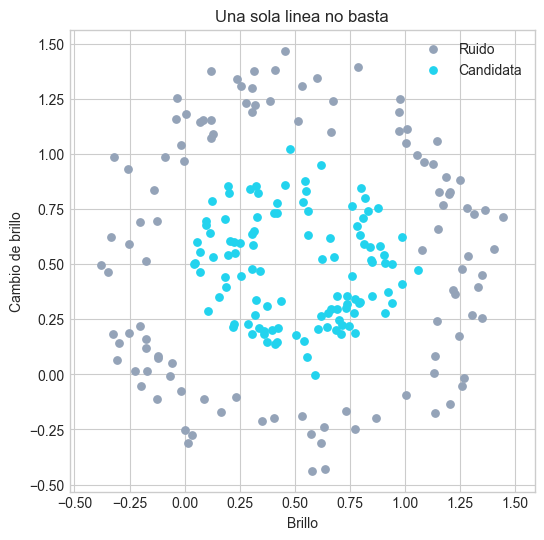

In [9]:
n_ring = 220
ang = np.random.uniform(0, 2 * np.pi, n_ring)

# Clase 1: senales candidatas en el centro
r_c = np.random.normal(0.35, 0.08, n_ring // 2)
x1 = np.column_stack([0.5 + r_c * np.cos(ang[:n_ring // 2]), 0.5 + r_c * np.sin(ang[:n_ring // 2])])

# Clase 0: ruido mas alejado
r_n = np.random.normal(0.8, 0.08, n_ring // 2)
x0 = np.column_stack([0.5 + r_n * np.cos(ang[n_ring // 2:]), 0.5 + r_n * np.sin(ang[n_ring // 2:])])

X_ring = np.vstack([x0, x1])
y_ring = np.array([0] * (n_ring // 2) + [1] * (n_ring // 2))

plt.figure(figsize=(6, 6))
plt.scatter(X_ring[y_ring == 0][:, 0], X_ring[y_ring == 0][:, 1], s=28, color='#94a3b8', label='Ruido')
plt.scatter(X_ring[y_ring == 1][:, 0], X_ring[y_ring == 1][:, 1], s=28, color='#22d3ee', label='Candidata')
plt.title('Una sola linea no basta')
plt.xlabel('Brillo')
plt.ylabel('Cambio de brillo')
plt.legend()
plt.axis('equal')
plt.show()

In [10]:
def step(z):
    return 1 if z >= 0 else 0

def perceptron_predict(x, w, b):
    z = np.dot(x, w) + b
    return step(z), z

w_ring = np.zeros(2)
b_ring = 0.0

for epoch in range(25):
    for xi, yi in zip(X_ring, y_ring):
        pred, _ = perceptron_predict(xi, w_ring, b_ring)
        e = yi - pred
        w_ring = w_ring + 0.12 * e * xi
        b_ring = b_ring + 0.12 * e

pred_ring = np.array([perceptron_predict(xi, w_ring, b_ring)[0] for xi in X_ring])
acc_ring = np.mean(pred_ring == y_ring)
print('Accuracy del perceptron en el caso no lineal:', round(float(acc_ring), 3))

Accuracy del perceptron en el caso no lineal: 0.5


<div style="
background-color:#ececec;
padding:24px;
border-radius:16px;
border:1.5px solid #b0b0b0;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h2 style="
margin-top:0;
color:#000000;
text-align:center;
font-size:34px;
font-family:'Palatino Linotype', Palatino, Georgia, serif;
font-weight:700;
letter-spacing:0.6px;
">
9. De un observatorio a una constelación de perceptrones
</h2>

<p>
Aquí aparece la idea de una <b>red neuronal</b>.
</p>

<p>
En lugar de usar una sola neurona, usamos varias:
</p>

<ul>
<li>Una capa de entrada recibe las mediciones.</li>
<li>Una capa oculta combina pistas intermedias.</li>
<li>Una capa de salida toma la decisión final.</li>
</ul>

<p>
Es como pasar de una sola pregunta a una cadena de preguntas conectadas.
</p>

</div>

<div style="
background-color:#ececec;
padding:24px;
border-radius:16px;
border:1.5px solid #b0b0b0;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h2 style="
margin-top:0;
color:#000000;
text-align:center;
font-size:34px;
font-family:'Palatino Linotype', Palatino, Georgia, serif;
font-weight:700;
letter-spacing:0.6px;
">
10. El toque que permite curvas
</h2>

<p>
Si cada neurona hiciera solo sumas lineales, la red seguiría siendo limitada.
</p>

<p>
Por eso se utilizan <b>funciones de activación no lineales</b>.
</p>

<p>
Gracias a esa no linealidad, la red puede aprender fronteras curvas y formas mucho más complejas.
</p>

</div>

In [11]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_deriv(a):
    return a * (1 - a)

Xn = (X_ring - X_ring.mean(axis=0)) / X_ring.std(axis=0)
y_col = y_ring.reshape(-1, 1)

rng = np.random.default_rng(9)
W1 = rng.normal(scale=0.8, size=(2, 6))
b1 = np.zeros((1, 6))
W2 = rng.normal(scale=0.8, size=(6, 1))
b2 = np.zeros((1, 1))

lr = 0.5
epochs = 5000
losses = []

for epoch in range(epochs):
    z1 = Xn @ W1 + b1
    a1 = sigmoid(z1)
    z2 = a1 @ W2 + b2
    a2 = sigmoid(z2)

    loss = np.mean((y_col - a2) ** 2)
    losses.append(loss)

    d_a2 = 2 * (a2 - y_col) / len(Xn)
    d_z2 = d_a2 * sigmoid_deriv(a2)
    d_W2 = a1.T @ d_z2
    d_b2 = np.sum(d_z2, axis=0, keepdims=True)

    d_a1 = d_z2 @ W2.T
    d_z1 = d_a1 * sigmoid_deriv(a1)
    d_W1 = Xn.T @ d_z1
    d_b1 = np.sum(d_z1, axis=0, keepdims=True)

    W2 -= lr * d_W2
    b2 -= lr * d_b2
    W1 -= lr * d_W1
    b1 -= lr * d_b1

pred_nn = (a2 >= 0.5).astype(int).ravel()
acc_nn = np.mean(pred_nn == y_ring)
print('Accuracy de la red neuronal:', round(float(acc_nn), 3))

Accuracy de la red neuronal: 0.995


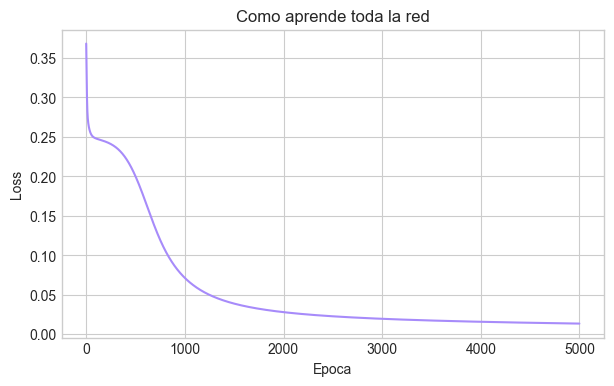

In [12]:
plt.figure(figsize=(7, 4))
plt.plot(losses, color='#a78bfa')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.title('Como aprende toda la red')
plt.show()

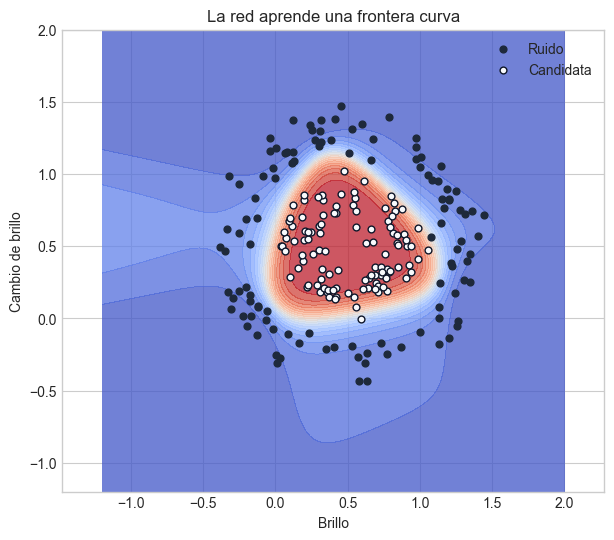

In [13]:
xx, yy = np.meshgrid(np.linspace(-1.2, 2.0, 300), np.linspace(-1.2, 2.0, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
gridn = (grid - X_ring.mean(axis=0)) / X_ring.std(axis=0)

a1g = sigmoid(gridn @ W1 + b1)
zg = sigmoid(a1g @ W2 + b2).reshape(xx.shape)

plt.figure(figsize=(7, 6))
plt.contourf(xx, yy, zg, levels=20, cmap='coolwarm', alpha=0.75)
plt.scatter(X_ring[y_ring == 0][:, 0], X_ring[y_ring == 0][:, 1], s=24, color='#1e293b', label='Ruido')
plt.scatter(X_ring[y_ring == 1][:, 0], X_ring[y_ring == 1][:, 1], s=24, color='#f8fafc', edgecolor='#0f172a', label='Candidata')
plt.title('La red aprende una frontera curva')
plt.xlabel('Brillo')
plt.ylabel('Cambio de brillo')
plt.legend()
plt.axis('equal')
plt.show()

<div style="
background-color:#ececec;
padding:24px;
border-radius:16px;
border:1.5px solid #b0b0b0;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h3 style="
margin-top:0;
color:#000000;
text-align:center;
font-size:30px;
font-family:'Palatino Linotype', Palatino, Georgia, serif;
font-weight:700;
letter-spacing:0.5px;
">
Interpretación de la gráfica
</h3>

<p>
Esta gráfica muestra que la red neuronal aprendió a encerrar las señales candidatas dentro de una región curva.
</p>

<p>
El color rojo representa la zona donde la red predice <b>señal candidata</b>, mientras que el azul corresponde a la región donde clasifica la señal como <b>ruido</b>.
</p>

<p>
Esto demuestra que, gracias a sus capas y a las funciones de activación, una red neuronal puede aprender <b>patrones no lineales</b>, algo que un perceptrón por sí solo no puede lograr.
</p>

</div>

<div style="
background-color:#ececec;
padding:24px;
border-radius:16px;
border:1.5px solid #b0b0b0;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h2 style="
margin-top:0;
color:#000000;
text-align:center;
font-size:34px;
font-family:'Palatino Linotype', Palatino, Georgia, serif;
font-weight:700;
letter-spacing:0.6px;
">
11. La misión que debe quedar
</h2>

<p>
La idea principal de toda esta analogía es esta:
</p>

<ul>
<li>El observatorio no adivina.</li>
<li>Recibe mediciones.</li>
<li>Combina pistas.</li>
<li>Decide.</li>
<li>Y mejora después de comparar sus errores.</li>
</ul>

<p>
Eso es justamente lo que hace una red neuronal.
</p>

</div>

In [14]:
def step(z):
    return 1 if z >= 0 else 0

def perceptron_predict(x, w, b):
    z = np.dot(x, w) + b
    return step(z), z

x = np.array([0.9, 0.7, 0.5, 0.8])
w = np.array([1.2, 1.0, 0.4, 0.8])
b = -1.6

pred, z = perceptron_predict(x, w, b)
print('Mediciones [brillo, cambio, color, claridad]:', x)
print('Pesos:', w)
print('Sesgo:', b)
print('Suma ponderada:', round(z, 3))
print('Decision del perceptron:', pred)

Mediciones [brillo, cambio, color, claridad]: [0.9 0.7 0.5 0.8]
Pesos: [1.2 1.  0.4 0.8]
Sesgo: -1.6
Suma ponderada: 1.02
Decision del perceptron: 1


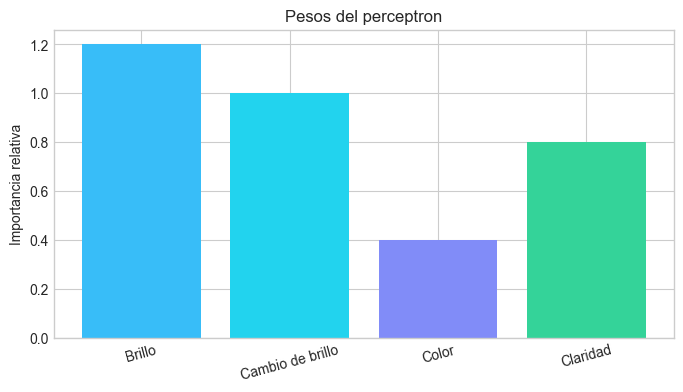

In [15]:
nombres = ['Brillo', 'Cambio de brillo', 'Color', 'Claridad']
pesos_demo = np.array([1.2, 1.0, 0.4, 0.8])

plt.figure(figsize=(8, 4))
plt.bar(nombres, pesos_demo, color=['#38bdf8', '#22d3ee', '#818cf8', '#34d399'])
plt.title('Pesos del perceptron')
plt.ylabel('Importancia relativa')
plt.xticks(rotation=15)
plt.show()

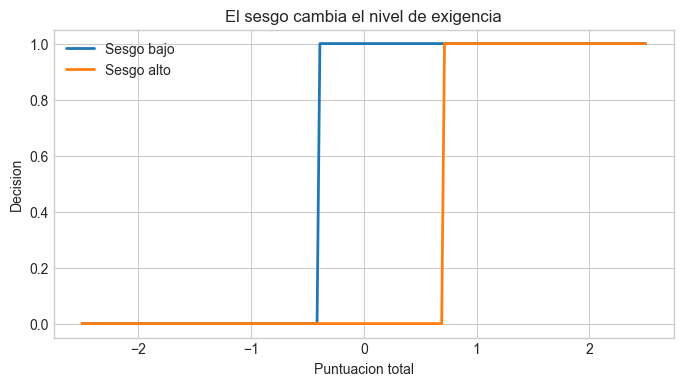

In [16]:
valores = np.linspace(-2.5, 2.5, 200)
decision_baja = [step(v + 0.4) for v in valores]
decision_alta = [step(v - 0.7) for v in valores]

plt.figure(figsize=(8, 4))
plt.plot(valores, decision_baja, label='Sesgo bajo', linewidth=2)
plt.plot(valores, decision_alta, label='Sesgo alto', linewidth=2)
plt.title('El sesgo cambia el nivel de exigencia')
plt.xlabel('Puntuacion total')
plt.ylabel('Decision')
plt.legend()
plt.show()

In [17]:
n = 120
brillo = np.random.uniform(0, 1, n)
cambio = np.random.uniform(0, 1, n)
color = np.random.uniform(0, 1, n)
claridad = np.random.uniform(0, 1, n)

X = np.column_stack([brillo, cambio, color, claridad])

# Regla sintetica para generar etiquetas.
# Aqui hacemos que brillo y cambio de brillo dominen para que la frontera lineal se vea clara.
score_real = 1.4 * brillo + 1.1 * cambio + 0.1 * color + 0.05 * claridad - 1.15
y = (score_real >= 0).astype(int)

print('Cantidad de senales:', len(X))
print('Candidatas:', int(y.sum()))
print('No candidatas:', int((1 - y).sum()))

Cantidad de senales: 120
Candidatas: 75
No candidatas: 45


In [18]:
X2 = X[:, :2]
y2 = y.copy()

w2 = np.zeros(2)
b2 = 0.0
lr = 0.15
epochs = 20
errors = []

for epoch in range(epochs):
    err = 0
    for xi, yi in zip(X2, y2):
        pred, _ = perceptron_predict(xi, w2, b2)
        e = yi - pred
        if e != 0:
            err += 1
        w2 = w2 + lr * e * xi
        b2 = b2 + lr * e
    errors.append(err)

preds2 = np.array([perceptron_predict(xi, w2, b2)[0] for xi in X2])
acc2 = np.mean(preds2 == y2)
print('Accuracy del perceptron:', round(float(acc2), 3))
print('Pesos aprendidos:', np.round(w2, 3))
print('Sesgo aprendido:', round(float(b2), 3))

Accuracy del perceptron: 0.967
Pesos aprendidos: [1.18  0.694]
Sesgo aprendido: -0.75


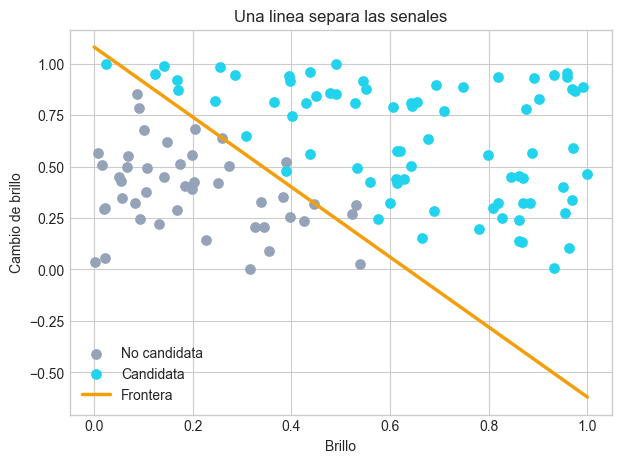

In [19]:
plt.figure(figsize=(7, 5))
plt.scatter(X2[y2 == 0][:, 0], X2[y2 == 0][:, 1], s=45, label='No candidata', color='#94a3b8')
plt.scatter(X2[y2 == 1][:, 0], X2[y2 == 1][:, 1], s=45, label='Candidata', color='#22d3ee')

xs = np.linspace(0, 1, 200)
ys = -(w2[0] * xs + b2) / w2[1]
plt.plot(xs, ys, color='#f59e0b', linewidth=2.5, label='Frontera')

plt.xlabel('Brillo')
plt.ylabel('Cambio de brillo')
plt.title('Una linea separa las senales')
plt.legend()
plt.show()

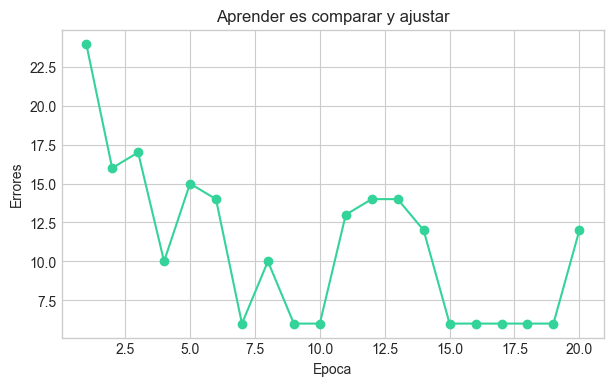

In [20]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, epochs + 1), errors, marker='o', color='#34d399')
plt.xlabel('Epoca')
plt.ylabel('Errores')
plt.title('Aprender es comparar y ajustar')
plt.show()